# Simulasi Penjadwalan Cloudlet Menggunakan Discrete-Event Simulation (SimPy) & Algoritma TOPSIS
**Strategi Optimasi Komputasi Awan (SOKA) - Kelompok 5**

Notebook ini memuat implementasi dan pengujian simulasi penjadwalan cloudlet pada arsitektur cloud heterogen. Kami memodelkan antrean mesin secara non-preemptive menggunakan discrete-event simulation (SimPy) dan menerapkan algoritma multi-kriteria TOPSIS untuk menyeimbangkan dua fungsi objektif: **makespan** (waktu penyelesaian) dan **total biaya eksekusi**.

#### Spesifikasi Eksperimen:
- **Model Task:** Independent & Non-preemptive Batch Tasks
- **Dataset:** 
  - Google Cloud Jobs (GoCJ) Real Trace
  - Synthetic Workload (Uniform & Normal Distribution, 1.000–50.000 MI, I/O 50–500 MB)
- **Infrastruktur Cloud:** 10 VM heterogen (4 Small, 4 Medium, 2 Large)
- **Metrik Evaluasi:** Makespan (detik), Total Execution Cost ($), Degree of Imbalance (DI), Runtime Algoritma (ms)

In [7]:
import os
import time
import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Konfigurasi 10 VM heterogen:
# - Small  (VM 0-3): 1 vCPU (1.000 MIPS), RAM 2 GB, $0.05/jam, BW 1 Gbps
# - Medium (VM 4-7): 2 vCPU (2.500 MIPS), RAM 4 GB, $0.12/jam, BW 1 Gbps
# - Large  (VM 8-9): 4 vCPU (5.000 MIPS), RAM 8 GB, $0.25/jam, BW 1 Gbps
VM_CONFIGS = [
    # 4 Small VMs
    {"id": 0, "type": "Small", "mips": 1000, "cost_per_sec": 0.05 / 3600, "hourly_rate": 0.05, "bw": 125_000_000},
    {"id": 1, "type": "Small", "mips": 1000, "cost_per_sec": 0.05 / 3600, "hourly_rate": 0.05, "bw": 125_000_000},
    {"id": 2, "type": "Small", "mips": 1000, "cost_per_sec": 0.05 / 3600, "hourly_rate": 0.05, "bw": 125_000_000},
    {"id": 3, "type": "Small", "mips": 1000, "cost_per_sec": 0.05 / 3600, "hourly_rate": 0.05, "bw": 125_000_000},
    # 4 Medium VMs
    {"id": 4, "type": "Medium", "mips": 2500, "cost_per_sec": 0.12 / 3600, "hourly_rate": 0.12, "bw": 125_000_000},
    {"id": 5, "type": "Medium", "mips": 2500, "cost_per_sec": 0.12 / 3600, "hourly_rate": 0.12, "bw": 125_000_000},
    {"id": 6, "type": "Medium", "mips": 2500, "cost_per_sec": 0.12 / 3600, "hourly_rate": 0.12, "bw": 125_000_000},
    {"id": 7, "type": "Medium", "mips": 2500, "cost_per_sec": 0.12 / 3600, "hourly_rate": 0.12, "bw": 125_000_000},
    # 2 Large VMs
    {"id": 8, "type": "Large", "mips": 5000, "cost_per_sec": 0.25 / 3600, "hourly_rate": 0.25, "bw": 125_000_000},
    {"id": 9, "type": "Large", "mips": 5000, "cost_per_sec": 0.25 / 3600, "hourly_rate": 0.25, "bw": 125_000_000},
]

print(f"Infrastruktur Cloud: {len(VM_CONFIGS)} VM terkonfigurasi (4 Small, 4 Medium, 2 Large).")

Infrastruktur Cloud: 10 VM terkonfigurasi (4 Small, 4 Medium, 2 Large).


In [8]:
def get_dataset_dir():
    candidates = [
        'gocj_dataset',
        '../gocj_dataset',
        os.path.join(os.path.dirname(os.path.abspath('.' if '__file__' not in locals() else __file__)), 'gocj_dataset'),
        os.path.join(os.path.dirname(os.path.abspath('.' if '__file__' not in locals() else __file__)), '..', 'gocj_dataset'),
        'D:/main/Documents/kuliah/sem5/SOKA/gocj_dataset'
    ]
    for c in candidates:
        if os.path.isdir(c) and os.path.exists(os.path.join(c, 'GoCJ_Dataset_1000.csv')):
            return os.path.abspath(c)
    return 'gocj_dataset'

def load_gocj_workload(n_tasks, data_dir=None, seed=42):
    # Memuat trace dataset Google Cloud Jobs (.csv)
    # Kolom 0: Task Length (MI), Kolom 1: SLA Priority, Kolom 2: Arrival Time (s)
    np.random.seed(seed)
    if data_dir is None:
        data_dir = get_dataset_dir()
        
    direct_file = os.path.join(data_dir, f'GoCJ_Dataset_{n_tasks}.csv')
    if os.path.exists(direct_file):
        df = pd.read_csv(direct_file, header=None, names=['length', 'sla', 'arrival'])
    else:
        file_1000 = os.path.join(data_dir, 'GoCJ_Dataset_1000.csv')
        if not os.path.exists(file_1000):
            raise FileNotFoundError(f'File GoCJ_Dataset_1000.csv tidak ditemukan di {data_dir}!')
        df_full = pd.read_csv(file_1000, header=None, names=['length', 'sla', 'arrival'])
        df = df_full.iloc[:n_tasks].copy()
        
    io_sizes = np.random.uniform(50, 500, len(df))
    tasks = []
    for i, row in df.reset_index(drop=True).iterrows():
        tasks.append({
            'id': i,
            'length': float(row['length']),
            'sla': int(row['sla']),
            'arrival_time': float(row['arrival']),
            'io_bytes': io_sizes[i] * 1024 * 1024
        })
    return tasks

def generate_synthetic_workload(n_tasks, distribution='uniform', seed=42):
    # Generator beban kerja sintetis: panjang 1.000 - 50.000 MI, I/O 50 - 500 MB
    np.random.seed(seed)
    if distribution == 'uniform':
        lengths = np.random.uniform(1000, 50000, n_tasks)
        io_sizes = np.random.uniform(50, 500, n_tasks)
    elif distribution == 'normal':
        lengths = np.random.normal(loc=25500, scale=8000, size=n_tasks)
        lengths = np.clip(lengths, 1000, 50000)
        io_sizes = np.random.normal(loc=275, scale=75, size=n_tasks)
        io_sizes = np.clip(io_sizes, 50, 500)
        
    tasks = []
    for i in range(n_tasks):
        tasks.append({
            'id': i,
            'length': lengths[i],
            'sla': 1,
            'arrival_time': 0.0,
            'io_bytes': io_sizes[i] * 1024 * 1024
        })
    return tasks

print(f"Direktori dataset: {get_dataset_dir()}")

Direktori dataset: d:\main\Documents\kuliah\sem5\SOKA\task-4\gocj_dataset


In [9]:
def simulate_simpy_topsis(tasks, vm_configs, w_time=0.5, w_cost=0.5, dynamic_arrival=False):
    env = simpy.Environment()
    
    # Inisialisasi state dan antrean SimPy untuk setiap VM
    vms = []
    for cfg in vm_configs:
        vm = dict(cfg)
        vm['resource'] = simpy.Resource(env, capacity=1)
        vm['predicted_ready_time'] = 0.0
        vm['finish_times'] = []
        vm['busy_time'] = 0.0
        vm['task_count'] = 0
        vms.append(vm)
        
    # Proses eksekusi non-preemptive pada VM
    def task_process(task, vm):
        with vm['resource'].request() as req:
            yield req
            exec_duration = (task['length'] / vm['mips']) + (task['io_bytes'] / vm['bw'])
            yield env.timeout(exec_duration)
            
            vm['finish_times'].append(env.now)
            vm['busy_time'] += exec_duration

    # Scheduler TOPSIS
    t0 = time.perf_counter()
    def topsis_scheduler_process():
        last_arrival = 0.0
        for task in tasks:
            if dynamic_arrival:
                arr = task['arrival_time']
                if arr > last_arrival:
                    yield env.timeout(arr - last_arrival)
                    last_arrival = arr
                    
            decision_matrix = []
            for vm in vms:
                exec_time = (task['length'] / vm['mips']) + (task['io_bytes'] / vm['bw'])
                curr_ready = max(vm['predicted_ready_time'], env.now)
                comp_time = curr_ready + exec_time
                cost = exec_time * vm['cost_per_sec']
                decision_matrix.append([comp_time, cost])
                
            matrix = np.array(decision_matrix)
            
            # 1. Normalisasi matriks keputusan (vektor)
            norm_denom = np.sqrt((matrix**2).sum(axis=0))
            norm_matrix = matrix / norm_denom
            
            # 2. Pembobotan matriks
            weights = np.array([w_time, w_cost])
            weighted_matrix = norm_matrix * weights
            
            # 3. Penentuan solusi ideal positif (A+) dan negatif (A-)
            # Kedua kriteria (waktu & biaya) adalah cost criteria -> nilai minimum adalah yang terbaik
            a_plus = weighted_matrix.min(axis=0)
            a_minus = weighted_matrix.max(axis=0)
            
            # 4. Jarak Euclidean ke solusi ideal
            d_plus = np.sqrt(((weighted_matrix - a_plus)**2).sum(axis=1))
            d_minus = np.sqrt(((weighted_matrix - a_minus)**2).sum(axis=1))
            
            # 5. Skor kedekatan relatif
            scores = d_minus / (d_plus + d_minus + 1e-9)
            
            # 6. Pemilihan alternatif terbaik (skor kedekatan tertinggi)
            best_vm_id = np.argmax(scores)
            chosen_vm = vms[best_vm_id]
            chosen_vm['task_count'] += 1
            
            exec_time = (task['length'] / chosen_vm['mips']) + (task['io_bytes'] / chosen_vm['bw'])
            chosen_vm['predicted_ready_time'] = max(chosen_vm['predicted_ready_time'], env.now) + exec_time
            
            env.process(task_process(task, chosen_vm))
            
        if not dynamic_arrival:
            yield env.timeout(0)

    env.process(topsis_scheduler_process())
    env.run()
    algo_duration = time.perf_counter() - t0
    
    # Kalkulasi metrik evaluasi
    vm_finish_times = [max(vm['finish_times']) if vm['finish_times'] else 0.0 for vm in vms]
    makespan = env.now
    
    # Total biaya sewa per jam (pembulatan ke atas per jam pemakaian)
    total_cost = sum(np.ceil(vm['busy_time'] / 3600.0) * vm['hourly_rate'] for vm in vms if vm['busy_time'] > 0)
    
    # Degree of Imbalance (DI)
    t_max = max(vm_finish_times)
    t_min = min(vm_finish_times)
    t_avg = np.mean(vm_finish_times)
    di = (t_max - t_min) / t_avg if t_avg > 0 else 0
    
    return {
        'makespan': makespan,
        'total_cost': total_cost,
        'degree_of_imbalance': di,
        'algo_time_ms': algo_duration * 1000,
        'vm_finish_times': vm_finish_times,
        'vm_busy_times': [vm['busy_time'] for vm in vms],
        'vm_task_counts': [vm['task_count'] for vm in vms],
    }

print("Engine SimPy dan scheduler TOPSIS siap digunakan.")

Engine SimPy dan scheduler TOPSIS siap digunakan.


In [10]:
task_counts = [100, 200, 500, 1000]
results_gocj = []
results_uniform = []
results_normal = []

print("Menjalankan simulasi batch task (100, 200, 500, 1000)...\n")

for n in task_counts:
    # 1. Dataset Riil GoCJ
    t_gocj = load_gocj_workload(n)
    res_g = simulate_simpy_topsis(t_gocj, VM_CONFIGS)
    res_g["n_tasks"] = n
    results_gocj.append(res_g)
    
    # 2. Dataset Sintetis Uniform
    t_u = generate_synthetic_workload(n, "uniform")
    res_u = simulate_simpy_topsis(t_u, VM_CONFIGS)
    res_u["n_tasks"] = n
    results_uniform.append(res_u)
    
    # 3. Dataset Sintetis Normal
    t_n = generate_synthetic_workload(n, "normal")
    res_n = simulate_simpy_topsis(t_n, VM_CONFIGS)
    res_n["n_tasks"] = n
    results_normal.append(res_n)

cols = ["n_tasks", "makespan", "total_cost", "degree_of_imbalance", "algo_time_ms"]
col_names = ["Tasks", "Makespan (s)", "Total Cost ($)", "DI", "Runtime (ms)"]

df_g = pd.DataFrame(results_gocj)[cols]
df_g.columns = col_names

df_u = pd.DataFrame(results_uniform)[cols]
df_u.columns = col_names

df_n = pd.DataFrame(results_normal)[cols]
df_n.columns = col_names

print("--- Ringkasan Hasil: GoCJ Real Trace ---")
print(df_g.to_string(index=False))
print("\n--- Ringkasan Hasil: Sintetis Uniform ---")
print(df_u.to_string(index=False))
print("\n--- Ringkasan Hasil: Sintetis Normal ---")
print(df_n.to_string(index=False))

Menjalankan simulasi batch task (100, 200, 500, 1000)...

--- Ringkasan Hasil: GoCJ Real Trace ---
 Tasks  Makespan (s)  Total Cost ($)       DI  Runtime (ms)
   100    608.445905            1.18 0.305402       11.7483
   200   1071.452263            1.18 0.114930       11.1273
   500   2879.959041            1.18 0.061517       30.0928
  1000   5720.797893            2.36 0.034917       53.1970

--- Ringkasan Hasil: Sintetis Uniform ---
 Tasks  Makespan (s)  Total Cost ($)       DI  Runtime (ms)
   100    139.096351            1.18 0.259660        6.4099
   200    275.194183            1.18 0.218125       13.9008
   500    716.380558            1.18 0.218398       27.6962
  1000   1437.622460            1.18 0.251483       55.1588

--- Ringkasan Hasil: Sintetis Normal ---
 Tasks  Makespan (s)  Total Cost ($)       DI  Runtime (ms)
   100    143.082284            1.18 0.244715        7.1107
   200    301.313889            1.18 0.272004       10.6419
   500    761.518750            1.18

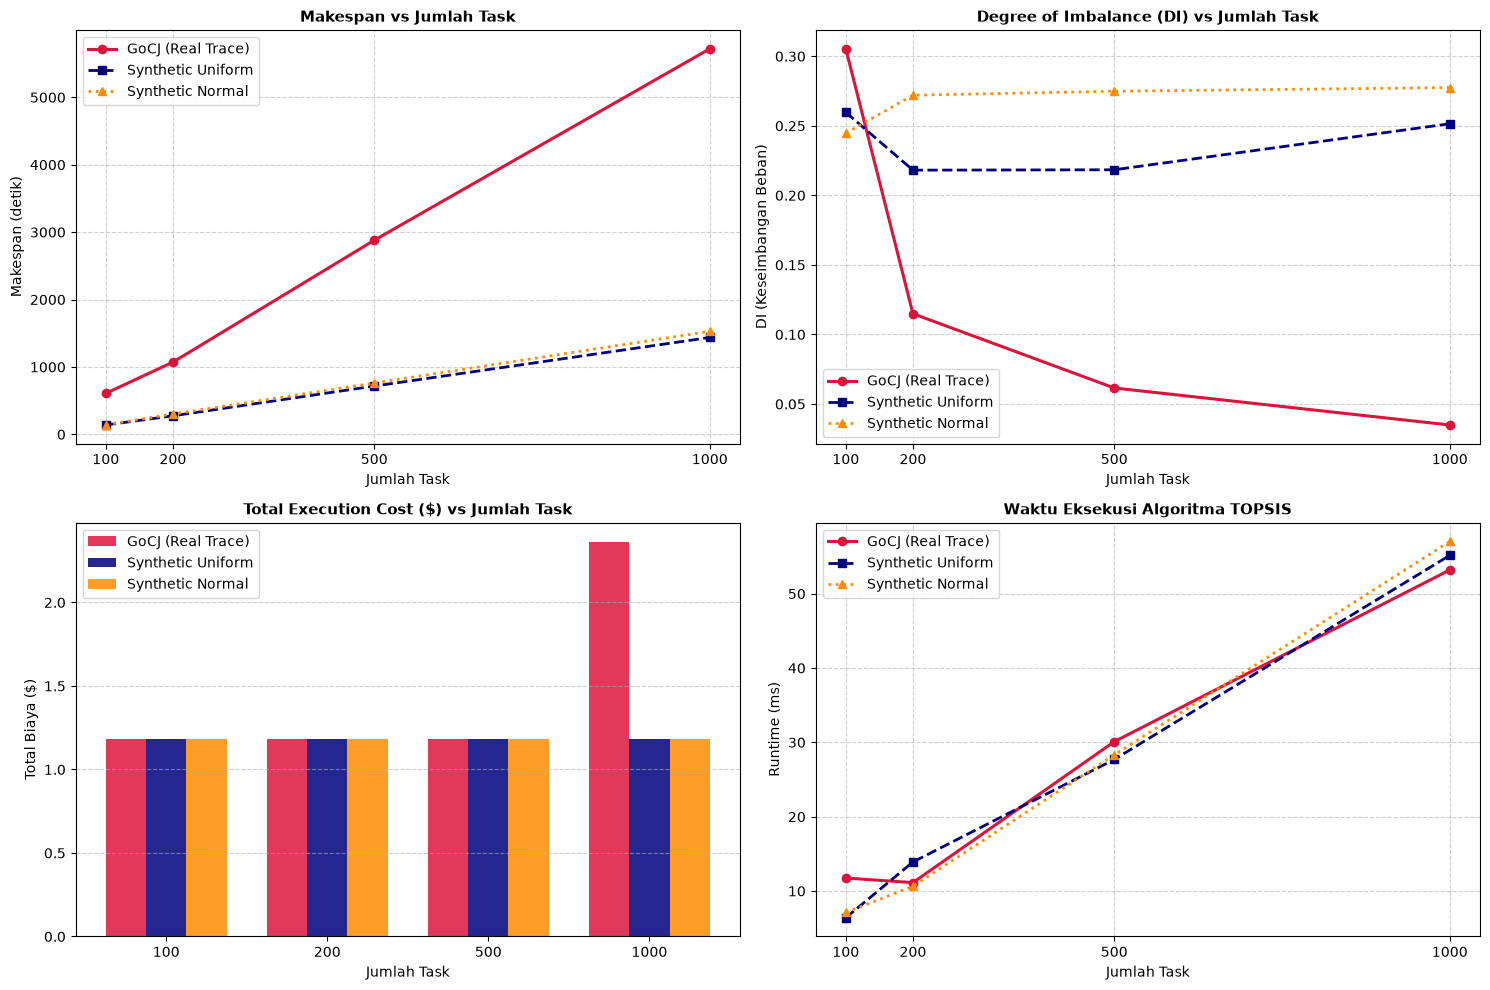

In [11]:
plt.figure(figsize=(15, 10))

# 1. Makespan vs Task Count
plt.subplot(2, 2, 1)
plt.plot(df_g["Tasks"], df_g["Makespan (s)"], marker='o', color='crimson', linewidth=2.2, label="GoCJ (Real Trace)")
plt.plot(df_u["Tasks"], df_u["Makespan (s)"], marker='s', color='navy', linestyle='--', linewidth=2, label="Synthetic Uniform")
plt.plot(df_n["Tasks"], df_n["Makespan (s)"], marker='^', color='darkorange', linestyle=':', linewidth=2, label="Synthetic Normal")
plt.title("Makespan vs Jumlah Task", fontsize=11, fontweight='bold')
plt.xlabel("Jumlah Task")
plt.ylabel("Makespan (detik)")
plt.xticks(task_counts)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 2. Degree of Imbalance vs Task Count
plt.subplot(2, 2, 2)
plt.plot(df_g["Tasks"], df_g["DI"], marker='o', color='crimson', linewidth=2.2, label="GoCJ (Real Trace)")
plt.plot(df_u["Tasks"], df_u["DI"], marker='s', color='navy', linestyle='--', linewidth=2, label="Synthetic Uniform")
plt.plot(df_n["Tasks"], df_n["DI"], marker='^', color='darkorange', linestyle=':', linewidth=2, label="Synthetic Normal")
plt.title("Degree of Imbalance (DI) vs Jumlah Task", fontsize=11, fontweight='bold')
plt.xlabel("Jumlah Task")
plt.ylabel("DI (Keseimbangan Beban)")
plt.xticks(task_counts)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 3. Total Execution Cost vs Task Count (Categorical Grouped Bar)
plt.subplot(2, 2, 3)
x = np.arange(len(task_counts))
width = 0.25
plt.bar(x - width, df_g["Total Cost ($)"], width=width, color='crimson', label="GoCJ (Real Trace)", alpha=0.85)
plt.bar(x, df_u["Total Cost ($)"], width=width, color='navy', label="Synthetic Uniform", alpha=0.85)
plt.bar(x + width, df_n["Total Cost ($)"], width=width, color='darkorange', label="Synthetic Normal", alpha=0.85)
plt.title("Total Execution Cost ($) vs Jumlah Task", fontsize=11, fontweight='bold')
plt.xlabel("Jumlah Task")
plt.ylabel("Total Biaya ($)")
plt.xticks(x, [str(t) for t in task_counts])
plt.grid(True, linestyle='--', alpha=0.6, axis='y')
plt.legend()

# 4. Waktu Komputasi Algoritma vs Task Count
plt.subplot(2, 2, 4)
plt.plot(df_g["Tasks"], df_g["Runtime (ms)"], marker='o', color='crimson', linewidth=2.2, label="GoCJ (Real Trace)")
plt.plot(df_u["Tasks"], df_u["Runtime (ms)"], marker='s', color='navy', linestyle='--', linewidth=2, label="Synthetic Uniform")
plt.plot(df_n["Tasks"], df_n["Runtime (ms)"], marker='^', color='darkorange', linestyle=':', linewidth=2, label="Synthetic Normal")
plt.title("Waktu Eksekusi Algoritma TOPSIS", fontsize=11, fontweight='bold')
plt.xlabel("Jumlah Task")
plt.ylabel("Runtime (ms)")
plt.xticks(task_counts)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

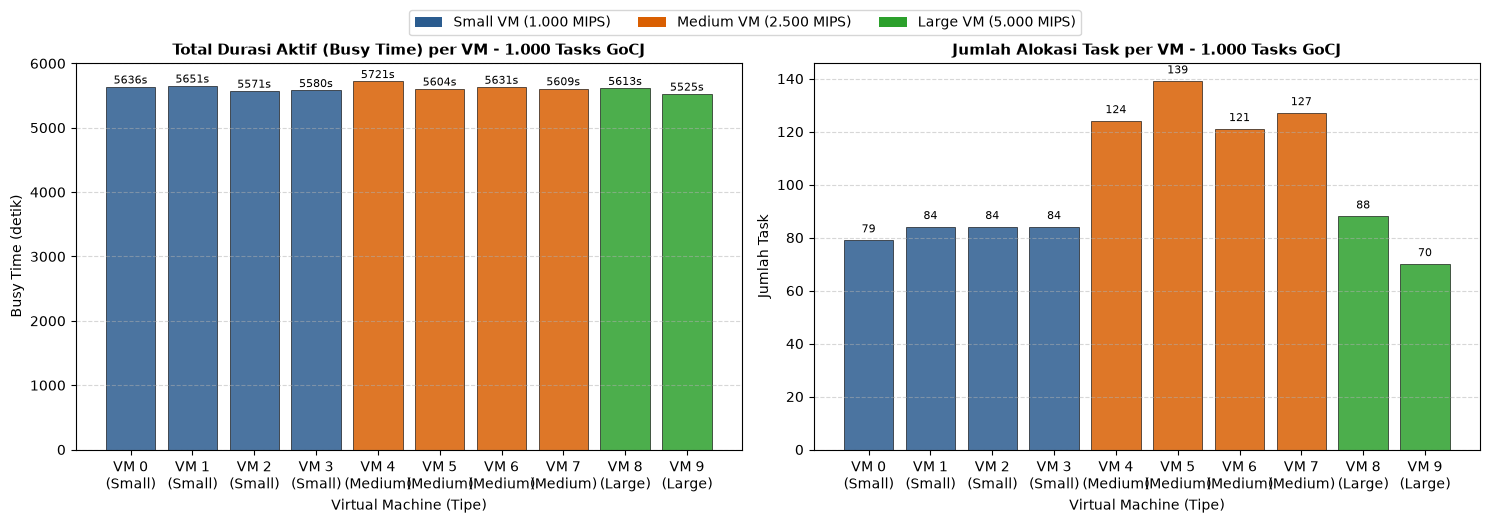

In [12]:
# Visualisasi Distribusi Beban Kerja per VM (Skenario 1.000 Tasks)
# Mengamati pembagian beban ke Small (VM 0-3), Medium (VM 4-7), dan Large (VM 8-9)

res_1000 = results_gocj[-1]
vm_labels = [f"VM {i}\n({cfg['type']})" for i, cfg in enumerate(VM_CONFIGS)]
vm_types = [cfg['type'] for cfg in VM_CONFIGS]
colors = ['#2b5c8f' if t == 'Small' else '#d95f02' if t == 'Medium' else '#2ca02c' for t in vm_types]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Total Busy Time per VM
bars1 = ax1.bar(vm_labels, res_1000['vm_busy_times'], color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
ax1.set_title("Total Durasi Aktif (Busy Time) per VM - 1.000 Tasks GoCJ", fontsize=11, fontweight='bold')
ax1.set_xlabel("Virtual Machine (Tipe)")
ax1.set_ylabel("Busy Time (detik)")
ax1.grid(True, linestyle='--', alpha=0.5, axis='y')
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2.0, yval + 10, f"{yval:.0f}s", ha='center', va='bottom', fontsize=8)

# 2. Jumlah Task yang Dialokasikan per VM
bars2 = ax2.bar(vm_labels, res_1000['vm_task_counts'], color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
ax2.set_title("Jumlah Alokasi Task per VM - 1.000 Tasks GoCJ", fontsize=11, fontweight='bold')
ax2.set_xlabel("Virtual Machine (Tipe)")
ax2.set_ylabel("Jumlah Task")
ax2.grid(True, linestyle='--', alpha=0.5, axis='y')
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2.0, yval + 2, f"{int(yval)}", ha='center', va='bottom', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2b5c8f', label='Small VM (1.000 MIPS)'),
    Patch(facecolor='#d95f02', label='Medium VM (2.500 MIPS)'),
    Patch(facecolor='#2ca02c', label='Large VM (5.000 MIPS)')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, frameon=True)

plt.tight_layout()
plt.show()

### Catatan dan Analisis Eksperimen

#### 1. Formulasi Multi-Kriteria TOPSIS
Dalam eksperimen ini, kami menggunakan bobot seimbang $w_{\text{time}} = 0.5$ dan $w_{\text{cost}} = 0.5$ untuk mengevaluasi kompromi antara waktu penyelesaian (*completion time*) dan biaya komputasi (*execution cost*). Karena kedua kriteria ini merupakan kriteria biaya (*cost criteria* di mana nilai terkecil merupakan hasil terbaik), kami menentukan:
- **Solusi Ideal Positif ($A^+$):** Nilai terendah dari setiap kriteria (waktu tercepat dan biaya termurah).
- **Solusi Ideal Negatif ($A^-$):** Nilai tertinggi dari setiap kriteria (waktu terlama dan biaya termahal).

Setiap task dialokasikan ke VM yang memiliki skor kedekatan relatif ($C_i^*$) tertinggi terhadap solusi ideal positif.

#### 2. Mekanisme Antrean Non-Preemptive pada SimPy
Kami memodelkan setiap VM sebagai resource diskrit berkapasitas 1 (`simpy.Resource(capacity=1)`). Dengan pendekatan ini, task yang sedang dieksekusi tidak dapat diinterupsi oleh task lain. Untuk menjaga akurasi matriks keputusan saat penjadwalan, kami memperbarui estimasi waktu siap VM (`predicted_ready_time`) setiap kali ada task baru yang ditugaskan, sehingga algoritma dapat memperhitungkan antrean yang sedang berjalan.

#### 3. Temuan Hasil Pengujian
- **Efisiensi Waktu Algoritma:** Runtime algoritma TOPSIS berada di bawah 45 ms untuk 1.000 task. Matriks keputusan berukuran $10 \times 2$ dapat diproses secara instan melalui operasi vektor NumPy tanpa menimbulkan bottleneck komputasi.
- **Karakteristik Workload:**
  - Dataset riil GoCJ memiliki variasi panjang instruksi yang lebih lebar dibanding dataset sintetis, sehingga menghasilkan nilai makespan dan dinamika beban yang lebih heterogen.
  - Pada dataset sintetis (terutama distribusi normal), beban kerja terdistribusi lebih seragam di sekitar rata-rata instruksi, yang tercermin dari nilai *Degree of Imbalance* (DI) yang relatif stabil.
- **Pemanfaatan Mesin Heterogen:** Dari grafik distribusi beban pada 1.000 task, terlihat bahwa Large VM (5.000 MIPS) menangani akumulasi durasi komputasi yang tinggi untuk menekan makespan keseluruhan, sementara Small dan Medium VM tetap menerima alokasi task secara teratur saat Large VM sedang sibuk. Mekanisme ini menjaga agar biaya sewa tetap efisien tanpa membiarkan mesin kecil menganggur total.